In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

from centrex_trajectories import (
    Coordinates,
    Gravity,
    Velocities,
    propagate_trajectories,
    PropagationOptions,
)
from centrex_trajectories.random_generation import (
    generate_random_coordinates_uniform_circle,
)
from centrex_trajectories.particles import TlF, Particle
from centrex_trajectories.beamline_objects import (
    ElectrostaticQuadrupoleLens,
    Bore,
)
from centrex_tlf import states, hamiltonian
from centrex_trajectories.utils import fit_stark_potential
from eigenshuffle import eigenshuffle_eigh

from physics_augment import (
    fit_stark_even_keep_domain,
    augment_with_physics_extended_smooth,
)
from data_creation import build_raw_dataset_full, load_raw_data_full, save_raw_data_full
from classifier_code import (
    Standardizer,
    train_classifier,
    evaluate_classifier,
    calibrate_temperature,
)

from regressor_code import (
    TrainCfgReg5,
    train_regressor5_slopes,
    SurrogateXYV,
    evaluate_regressor5,
)
from visualize import compute_error_maps_full, show_error_plots_full

import torch

In [2]:
plt.rcParams.update({"font.size": 14})


In [3]:
rng = np.random.default_rng(seed=42)  # For reproducibility

In [4]:
device = "cpu"

In [5]:
# # generate states up to J=6
# QN = states.generate_uncoupled_states_ground(Js=np.arange(7))

# # generate the X hamiltonian terms
# H = hamiltonian.generate_uncoupled_hamiltonian_X(QN)

# # create a function outputting the hamiltonian as a function of E and B
# Hfunc = hamiltonian.generate_uncoupled_hamiltonian_X_function(H)

# # V/cm
# Ez = np.linspace(0, 50e3, 2_001)

# # generate the Hamiltonian for (almost) zero field, add a small field to make states
# # non-degenerate
# Hi = Hfunc(E=[0, 0, 1e-3], B=[0, 0, 1e-3])
# E, V = np.linalg.eigh(Hi)

# # run eigenshuffle to track the states
# Ez = np.append(np.linspace(0, 1_000, 501), np.linspace(2_000, 50_000, 51))
# hamiltonians = np.array([Hfunc(E=[0, 0, Ei], B=[0, 0, 1e-3]) for Ei in Ez])
# es, vs = eigenshuffle_eigh(hamiltonians)

# # get the true superposition-states of the system
# QN_states = hamiltonian.matrix_to_states(vs[0], QN)


In [6]:
# indices_J2 = [idx for idx, s in enumerate(QN_states) if s.largest.J == 2]

# indices_J2_F3 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )
# indices_J2_other = [idx for idx in indices_J2 if idx not in indices_J2_F3]

# indices_J2_mF0 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 0 and qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )

# indices_J2_mF2 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 2 and qn.largest.F == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )

# indices_J2_mF3 = (
#     indices_J2[0]
#     + np.where(
#         [
#             qn.largest.mF == 3
#             for qn in [
#                 qn.remove_small_components().transform_to_coupled()
#                 for qn in [QN_states[idx] for idx in indices_J2]
#             ]
#         ]
#     )[0]
# )


In [7]:
# # convert to V/m
# Ez_Vm = Ez * 100

# # grab energy of J=2, mF=0, 2 & 3
# # mF=-1,0,1 have more or less the same energy levels, just slight differences at higher
# # fields
# energy = es.real[:, indices_J2_mF0[0]] * constants.hbar
# fit_coeff_mF0 = fit_stark_potential(Ez_Vm, energy, deg=11)

# energy = es.real[:, indices_J2_mF2[0]] * constants.hbar
# fit_coeff_mF2 = fit_stark_potential(Ez_Vm, energy, deg=11)

# energy = es.real[:, indices_J2_mF3[0]] * constants.hbar
# fit_coeff_mF3 = fit_stark_potential(Ez_Vm, energy, deg=11)


In [8]:
def run_trajectory_simulation(
    R: float,
    V: float,
    L: float,
    n_trajectories: int,
    rng,
    options: PropagationOptions,
    particle: Particle,
    gravity: Gravity,
):
    origin = generate_random_coordinates_uniform_circle(
        radius=R, number=n_trajectories, x=0, y=0, z=-1e-2, rng=rng
    )
    velocities = Velocities(
        rng.uniform(-10, 10, n_trajectories),
        rng.uniform(-10, 10, n_trajectories),
        rng.uniform(100, 250, n_trajectories),
    )

    eql = ElectrostaticQuadrupoleLens(
        name="Electrostatic Lens",
        objects=[
            Bore(
                x=0,
                y=0,
                z=0,
                length=L,
                radius=R,
            )
        ],
        start=0,
        stop=L,
        V=V,
        R=R,
        save_collisions=True,
    )

    sections = [eql]
    section_data, trajectories = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=options,
    )
    dt = -origin.z / velocities.vz
    coords_init = Coordinates(
        x=origin.x + velocities.vx * dt,
        y=origin.y + velocities.vy * dt,
        z=np.zeros_like(origin.z),
    )
    velocities_init = velocities
    coords_final, velocities_final = (
        trajectories.get_coordinates_velocities_at_position(z=L)
    )
    indices_survive = np.array(list(trajectories.keys()))
    return coords_init, coords_final, velocities_init, velocities_final, indices_survive

In [9]:
# 1) Fit Stark, get alpha0 (you already have this step)
# P_t, alpha0 = fit_stark_even_keep_domain(Ez_Vm, energy, deg_even=12)
alpha0 = np.float64(3.42909943128328e-49)

# 2) Build training data across voltages
rng = np.random.default_rng(seed=42)
particle = TlF()
gravity = Gravity(0, -9.81 * particle.mass, 0)
options = PropagationOptions(verbose=False, n_cores=8)
L = 0.6
R = 1.75 * 25.4e-3 / 2

In [10]:
try:
    data_tr_full, meta_tr = load_raw_data_full("data_tr_full.npz")
    data_va_full, meta_va = load_raw_data_full("data_va_full.npz")
    data_te_full, meta_te = load_raw_data_full("data_te_full.npz")
except:
    V_list = np.linspace(0, 30_000, 11)
    # 1) Rebuild splits with velocities (you can keep your existing classifier)
    #    If you already have data_tr/va/te for classifier, you can just build here for regressor:

    per_V_train, per_V_val, per_V_test = 100_000, 40_000, 100_000

    meta_train = {
        "V_list": list(V_list),  # list of lens voltages
        "R": R,  # lens bore radius [m]
        "L": L,  # lens length [m]
        "per_V": {  # number of trajectories per voltage
            "train": per_V_train,
            "val": per_V_val,
            "test": per_V_test,
        },
        "split": "train",  # dataset split
        "mass": particle.mass,  # optional: molecule or atom
        "gravity": (gravity.fx, gravity.fy, gravity.fz),  # if used in simulation
    }

    data_tr_full = build_raw_dataset_full(
        V_list,
        per_V_train,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )
    data_va_full = build_raw_dataset_full(
        V_list,
        per_V_val,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )
    data_te_full = build_raw_dataset_full(
        V_list,
        per_V_test,
        R,
        L,
        rng,
        options,
        particle,
        gravity,
        run_trajectory_simulation,
    )

    save_raw_data_full(
        data_tr_full,
        "data_tr_full.npz",
        meta=meta_train,
    )

    meta_val = meta_train | {"split": "val"}
    meta_test = meta_train | {"split": "test"}

    save_raw_data_full(data_va_full, "data_va_full.npz", meta=meta_val)
    save_raw_data_full(data_te_full, "data_te_full.npz", meta=meta_test)

In [11]:
data_tr_full.X = augment_with_physics_extended_smooth(
    data_tr_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

data_va_full.X = augment_with_physics_extended_smooth(
    data_va_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

# For test later:
data_te_full.X = augment_with_physics_extended_smooth(
    data_te_full.X, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

In [12]:
# 1) Standardize inputs from TRAIN ONLY
stdX = Standardizer(data_tr_full.X)
muX, sdX = stdX.torch(device)

# 2) Train classifier (focal + mining)
clf = train_classifier(
    data_tr_full,
    data_va_full,
    mu=stdX.mu,
    sd=stdX.sd,
    device=device,
    epochs=40,  # Moderate (between 15 and 30)
    batch=8192,
    lr=3e-4,  # Moderate (between 5e-5 and 5e-3)
    wd=1e-3,  # Strong but not extreme (between 1e-3 and 2e-2)
    gamma=1.0,  # Low focal loss (between 0.0 and 1.5)
    alpha=None,
    patience=8,  # Moderate (between 3 and 10)
    pdrop=0.1,  # Moderate dropout (between 0.1 and 0.5)
    input_drop=0.1,  # Moderate input dropout (between 0.1 and 0.5)
    hidden=(256, 128, 64),  # Keep reasonable size
)

# 3) Calibrate temperature on VALID (minimize Brier)
temp_scale = calibrate_temperature(
    clf, data_va_full.X, data_va_full.y, stdX.mu, stdX.sd, device
)
print(f"[CAL] Temperature scale exp(T) = {temp_scale:.3f}")

# 4) Evaluate on VALID (and pick threshold)
val_metrics = evaluate_classifier(
    clf, data_va_full, stdX.mu, stdX.sd, device, thr=None, tag="VALID"
)
thr_used = val_metrics["thr"]

# 5) Evaluate on TEST with fixed threshold
test_metrics = evaluate_classifier(
    clf, data_te_full, stdX.mu, stdX.sd, device, thr=thr_used, tag="TEST"
)

# 6) Bundle 'metrics' for downstream use
metrics: dict[str, float] = {"threshold_used": float(thr_used)}
print("Classifier ready. Using threshold:", metrics["threshold_used"])


[CLS] Epoch 1/40: 100%|██████████| 131/131 [00:12<00:00, 10.91it/s]


[CLS] Epoch 1: train_loss=0.1253  val_loss=0.0336


[CLS] Epoch 2/40: 100%|██████████| 51/51 [00:04<00:00, 11.44it/s]


[CLS] Epoch 2: train_loss=0.1211  val_loss=0.0945


[CLS] Epoch 3/40: 100%|██████████| 71/71 [00:05<00:00, 12.05it/s]


...

[CLS] Epoch 11: train_loss=0.1015  val_loss=0.0356


[CLS] Epoch 12/40: 100%|██████████| 51/51 [00:04<00:00, 12.42it/s]


[CLS] Epoch 12: train_loss=0.0953  val_loss=0.0823


[CLS] Epoch 13/40: 100%|██████████| 65/65 [00:05<00:00, 12.21it/s]


[CLS] Epoch 13: train_loss=0.1034  val_loss=0.0480
[CLS] Early stop @ 13 (best val=0.0301)
[CAL] Temperature scale exp(T) = 0.207
=== Survival (VALID) ===
Accuracy          : 0.979
Balanced accuracy : 0.979
ROC-AUC           : 0.990
PR-AUC            : 0.916
Brier score       : 0.01701
Threshold         : 0.400
Confusion (tp, fp, fn, tn): 148829, 6010, 3330, 281831
=== Survival (TEST) ===
Accuracy          : 0.979
Balanced accuracy : 0.979
ROC-AUC           : 0.990
PR-AUC            : 0.916
Brier score       : 0.01676
Threshold         : 0.400
Confusion (tp, fp, fn, tn): 371622, 14925, 8196, 705257
Classifier ready. Using threshold: 0.39978964264092076


In [13]:
# Survivors only
surv_tr = data_tr_full.mask_surv

# Get RAW 6-D from the already-augmented matrix by slicing the first 6 cols
if data_tr_full.X.shape[1] >= 6:
    X_surv_raw_tr = data_tr_full.X[surv_tr, :6].astype(np.float32)  # [x0,y0,vx,vy,vz,V]
else:
    X_surv_raw_tr = data_tr_full.X[surv_tr].astype(np.float32)  # already raw 6-D

# Physics-augmented inputs for the regressor (extended features)
X_surv_aug_tr = augment_with_physics_extended_smooth(
    X_surv_raw_tr, R=R, L=L, alpha0=alpha0, mass=particle.mass
).astype(np.float32)

# Targets
Y_surv_tr = np.column_stack(
    [
        data_tr_full.xf[surv_tr],
        data_tr_full.yf[surv_tr],
        data_tr_full.vxf[surv_tr],
        data_tr_full.vyf[surv_tr],
        data_tr_full.vzf[surv_tr],
    ]
).astype(np.float32)

# cfg_reg = TrainCfgReg5(epochs=50, lr=1e-3, weight_decay=1e-3)
cfg_reg = TrainCfgReg5(epochs=50)

# Normalizer for the regressor feature space (17-D)
std_aug = Standardizer(X_surv_aug_tr)
muX_aug, sdX_aug = std_aug.torch(cfg_reg.device)

# Train
reg5, scalerY = train_regressor5_slopes(
    X_surv_aug_tr,
    Y_surv_tr,
    X_surv_raw_tr,
    muX_aug.cpu().numpy(),
    sdX_aug.cpu().numpy(),
    R,
    cfg_reg,
    L=L,
    alpha0=alpha0,
    mass=particle.mass,
)


[REG5] Epoch 1/50: 100%|██████████| 42/42 [00:07<00:00,  5.49it/s]


[REG5] Epoch 1: train_loss=0.1091  val_loss=0.0272


[REG5] Epoch 2/50: 100%|██████████| 42/42 [00:08<00:00,  5.03it/s]


[REG5] Epoch 2: train_loss=0.0145  val_loss=0.0076


[REG5] Epoch 3/50: 100%|██████████| 42/42 [00:07<00:00,  5.60it/s]


...

[REG5] Epoch 33: train_loss=0.0012  val_loss=0.0007


[REG5] Epoch 34/50: 100%|██████████| 42/42 [00:07<00:00,  5.70it/s]


[REG5] Epoch 34: train_loss=0.0011  val_loss=0.0007


[REG5] Epoch 35/50: 100%|██████████| 42/42 [00:07<00:00,  5.72it/s]


[REG5] Epoch 35: train_loss=0.0011  val_loss=0.0007
[REG5] Early stop @ 35 (best val=0.0008)


In [14]:
metrics_regressor = evaluate_regressor5(
    reg5,
    data_te_full.X[:, :6].astype(
        np.float32
    ),  # RAW [x0,y0,vx,vy,vz,V] from first 6 cols
    data_te_full.xf,
    data_te_full.yf,
    data_te_full.vxf,
    data_te_full.vyf,
    data_te_full.vzf,
    data_te_full.y,
    muX_aug.cpu().numpy(),  # 17-D regressor feature stats (from TRAIN survivors)
    sdX_aug.cpu().numpy(),  # 17-D regressor feature stats (from TRAIN survivors)
    scalerY,
    R,
    cfg_reg.device,
    tag="TEST",
    augment_fn=augment_with_physics_extended_smooth,  # same function used in training
    alpha0=alpha0,
    mass=particle.mass,
    L=L,
)


=== Final state (TEST, TRUE survivors) ===
POS  MAE: x=0.028 mm, y=0.027 mm   RMSE: x=0.086 mm, y=0.085 mm
POS  R² : x=0.9999, y=0.9999   Radial P50=0.029 mm, P90=0.079 mm, P99=0.251 mm
VEL  MAE: vx=0.021 m/s, vy=0.020 m/s, vz=0.389 m/s
VEL RMSE: vx=0.139 m/s, vy=0.145 m/s, vz=0.543 m/s
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998


=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.028 mm, y=0.027 mm   RMSE: x=0.087 mm, y=0.087 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.077 mm, P99=0.241 mm  
VEL  MAE: vx=0.021 m/s, vy=0.020 m/s, vz=0.380 m/s  
VEL RMSE: vx=0.142 m/s, vy=0.148 m/s, vz=0.523 m/s  
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998  

=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.181 mm, y=0.189 mm   RMSE: x=0.307 mm, y=0.315 mm  
POS  R² : x=0.9993, y=0.9992   Radial P50=0.224 mm, P90=0.509 mm, P99=1.504 mm  
VEL  MAE: vx=0.084 m/s, vy=0.085 m/s, vz=0.269 m/s  
VEL RMSE: vx=0.183 m/s, vy=0.185 m/s, vz=0.379 m/s  
VEL   R²: vx=0.9983, vy=0.9983, vz=0.9999  


=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.027 mm, y=0.028 mm   RMSE: x=0.088 mm, y=0.088 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.079 mm, P99=0.216 mm  
VEL  MAE: vx=1543.663 m/s, vy=1695.642 m/s, vz=0.304 m/s  
VEL RMSE: vx=2256.109 m/s, vy=2376.797 m/s, vz=0.417 m/s  
VEL   R²: vx=-256701.0605, vy=-285244.0020, vz=0.9999  

=== Final state (TEST, TRUE survivors) ===  
POS  MAE: x=0.028 mm, y=0.027 mm   RMSE: x=0.087 mm, y=0.086 mm  
POS  R² : x=0.9999, y=0.9999   Radial P50=0.030 mm, P90=0.077 mm, P99=0.234 mm  
VEL  MAE: vx=0.021 m/s, vy=0.021 m/s, vz=0.388 m/s  
VEL RMSE: vx=0.141 m/s, vy=0.148 m/s, vz=0.539 m/s  
VEL   R²: vx=0.9990, vy=0.9989, vz=0.9998  

In [15]:
# --- CLASSIFIER normalizer (what you used when training clf)
# If your classifier used RAW 6-D features:
muX_clf = stdX.mu  # length 6
sdX_clf = stdX.sd  # length 6
augment_fn_clf = augment_with_physics_extended_smooth  # classifier trained on raw

# If it was trained on augmented too, use the augmented stats & augment_fn here instead.
# muX_clf, sdX_clf = muX_aug_clf, sdX_aug_clf
# augment_fn_clf = augment_with_physics

# --- REGRESSOR normalizer — you just computed these on 12-D augmented survivors
muX_reg = muX_aug.cpu().numpy()  # length 12
sdX_reg = sdX_aug.cpu().numpy()  # length 12
augment_fn_reg = augment_with_physics_extended_smooth  # MUST match training

sg_xyv = SurrogateXYV(
    clf=clf,
    reg5=reg5,
    muX_clf=muX_clf,
    sdX_clf=sdX_clf,  # for classifier path
    muX_reg=muX_reg,
    sdX_reg=sdX_reg,  # 12-D augmented stats (regressor)
    scalerY=scalerY,
    R=R,
    L=L,
    alpha0=alpha0,
    mass=particle.mass,
    device=cfg_reg.device,
    thr=metrics["threshold_used"],
    augment_fn_clf=augment_fn_clf,
    augment_fn_reg=augment_fn_reg,
)

In [16]:
mask = data_te_full.y.astype(bool)
Xraw_te = data_te_full.X[:, :6].astype(np.float32)  # [x0,y0,vx,vy,vz,V]

emap = compute_error_maps_full(
    x_true=data_te_full.xf[mask],
    y_true=data_te_full.yf[mask],
    vx_true=data_te_full.vxf[mask],
    vy_true=data_te_full.vyf[mask],
    vz_true=data_te_full.vzf[mask],
    x_pred=metrics_regressor["x_pred"],
    y_pred=metrics_regressor["y_pred"],
    vx_pred=metrics_regressor["vx_pred"],
    vy_pred=metrics_regressor["vy_pred"],
    vz_pred=metrics_regressor["vz_pred"],
    x0=Xraw_te[mask, 0],
    y0=Xraw_te[mask, 1],
    vz0=Xraw_te[mask, 4],
    R=R,
)


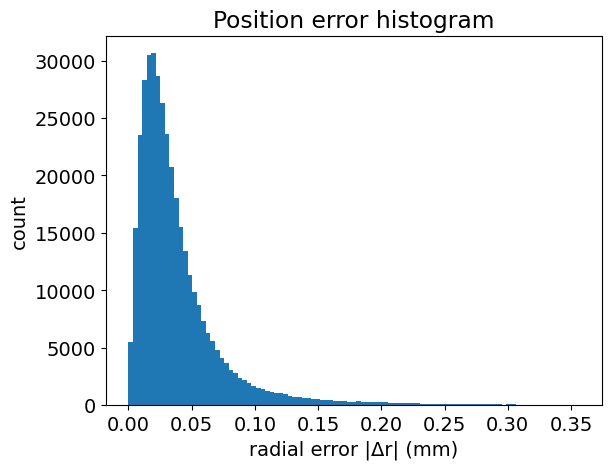

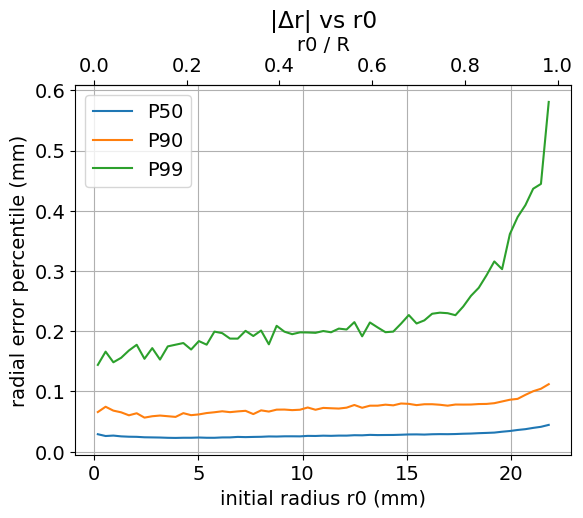

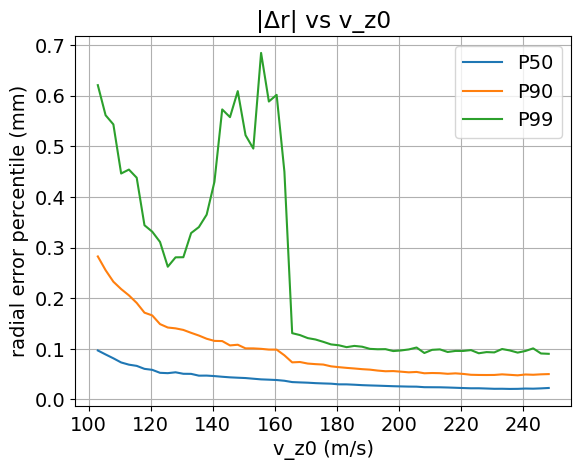

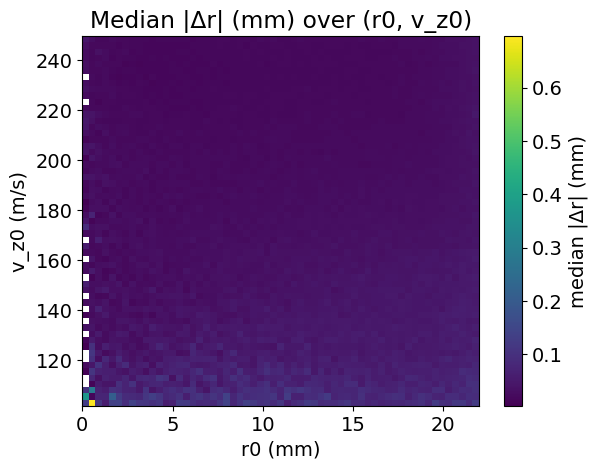

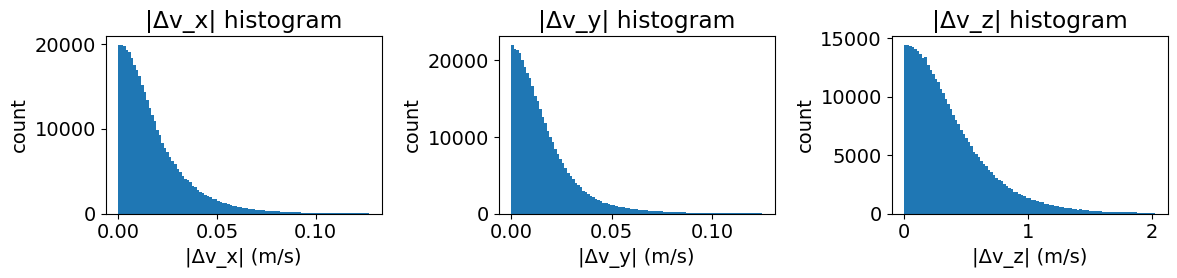

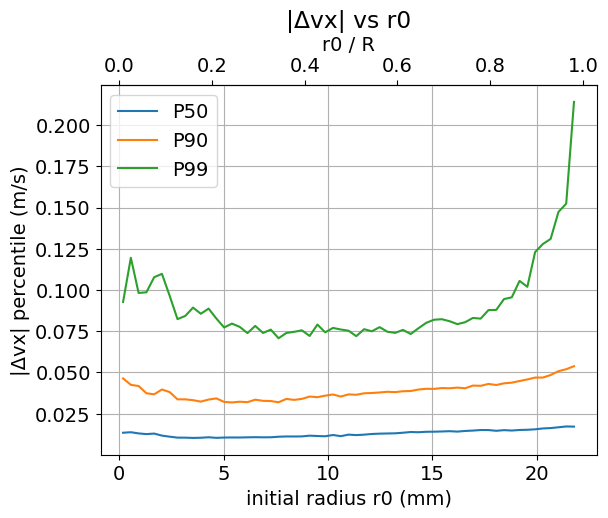

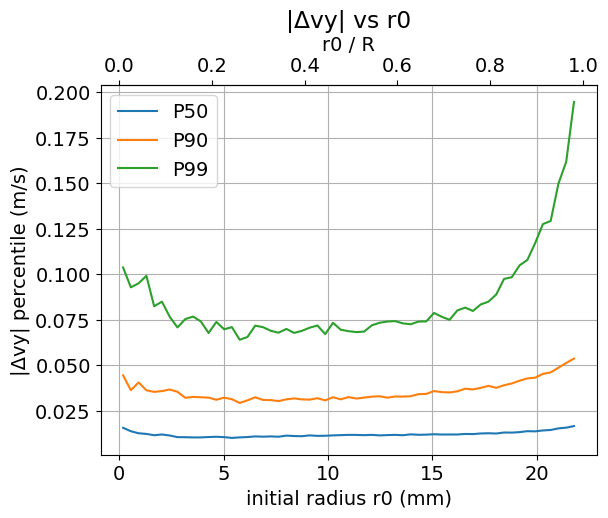

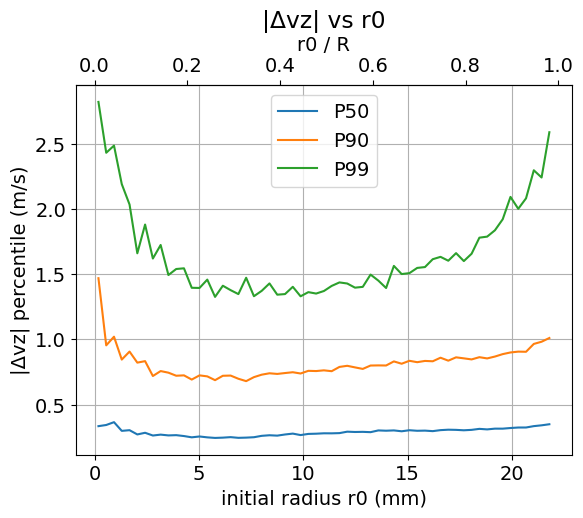

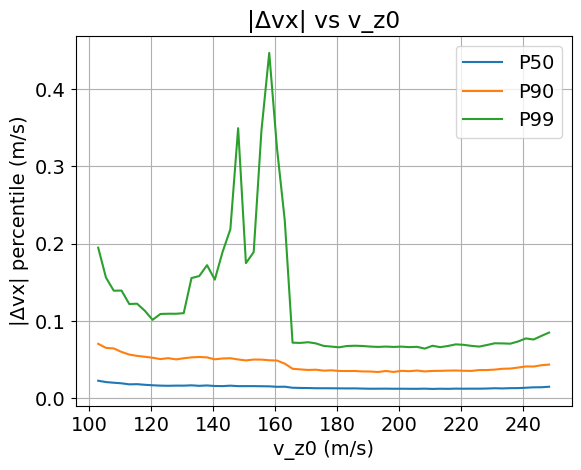

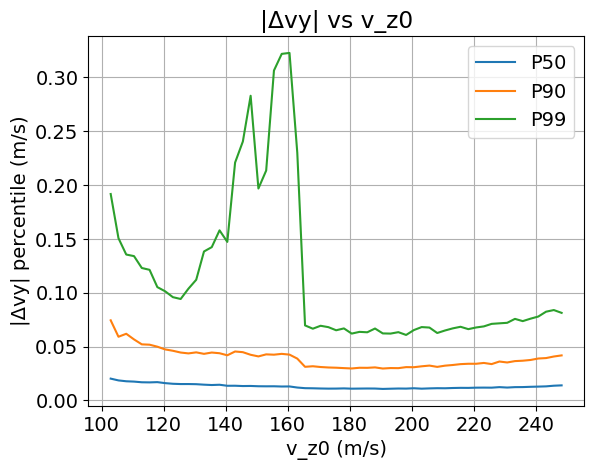

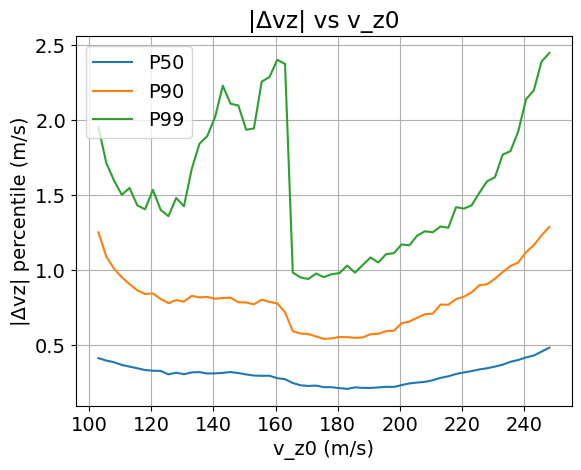

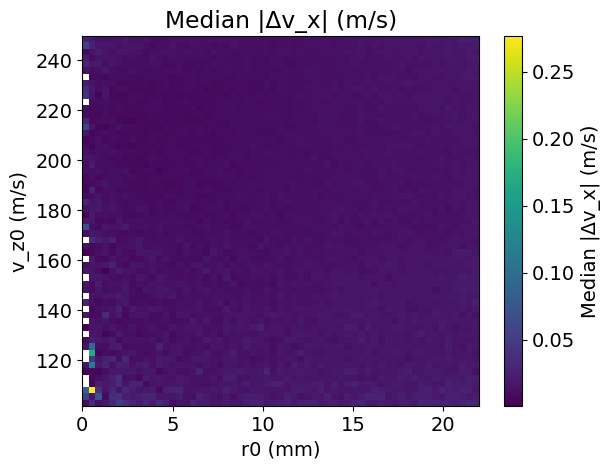

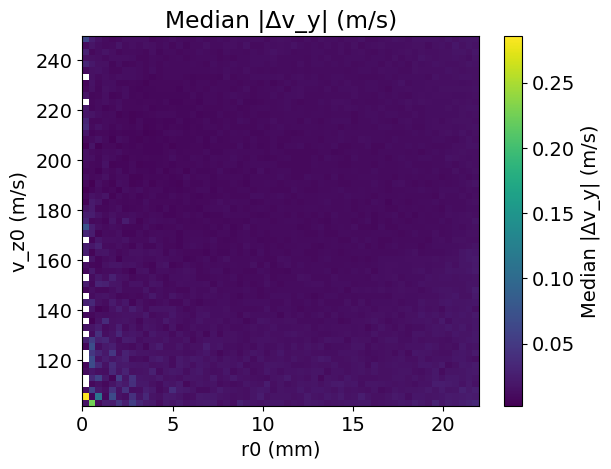

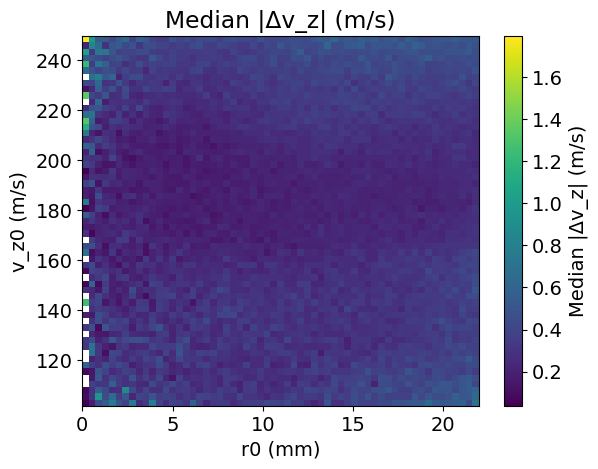

In [17]:
show_error_plots_full(emap, R=R)

In [18]:
n_eval = 20_000

x0 = rng.uniform(-0.8 * R, 0.8 * R, n_eval).astype(np.float32)
y0 = rng.uniform(-0.8 * R, 0.8 * R, n_eval).astype(np.float32)
vx = rng.uniform(-10.0, 10.0, n_eval).astype(np.float32)
vy = rng.uniform(-10.0, 10.0, n_eval).astype(np.float32)
vz = rng.uniform(100.0, 250.0, n_eval).astype(np.float32)
V_eval = np.full(n_eval, 20_000.0, dtype=np.float32)  # choose any voltage in-range


p, survive, x_out, y_out, vx_out, vy_out, vz_out = sg_xyv.predict(
    x0,
    y0,
    vx,
    vy,
    vz,
    V_eval,  # V_eval can be array or scalar like 25_000
)

In [19]:
%%timeit
p, survive, x_out, y_out, vx_out, vy_out, vz_out = sg_xyv.predict(
    x0,
    y0,
    vx,
    vy,
    vz,
    V_eval,  # V_eval can be array or scalar like 25_000
)

57.7 ms ± 2.43 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Text(0.5, 1.0, 'Survivor density')

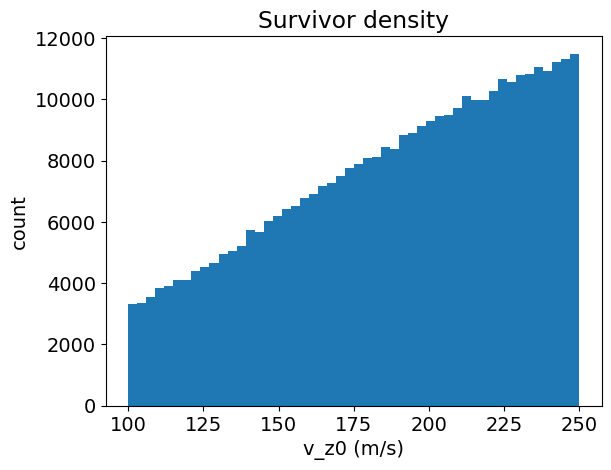

In [20]:
plt.hist(emap["vz0"], bins=50)
plt.xlabel("v_z0 (m/s)")
plt.ylabel("count")
plt.title("Survivor density")


Text(0, 0.5, '|Δr| (mm)')

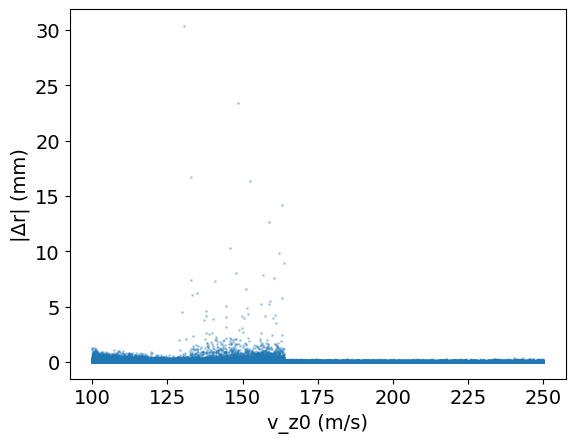

In [21]:
plt.scatter(emap["vz0"], emap["rerr"] * 1e3, s=1, alpha=0.3)
plt.xlabel("v_z0 (m/s)")
plt.ylabel("|Δr| (mm)")

c:\Users\ogras\Documents\GitHub\CeNTREX-trajectories\Examples\surrogates\physics_augment.py:417: RuntimeWarning: invalid value encountered in scalar divide
  k2 = (alpha0 * (G * G)) / (mass_kg * vz * vz)
c:\Users\ogras\Documents\GitHub\CeNTREX-trajectories\Examples\surrogates\physics_augment.py:233: RuntimeWarning: invalid value encountered in divide
  x_exit[~mask] = x0[~mask] + (vx0[~mask] / vz0[~mask]) * L
c:\Users\ogras\Documents\GitHub\CeNTREX-trajectories\Examples\surrogates\physics_augment.py:234: RuntimeWarning: invalid value encountered in divide
  y_exit[~mask] = y0[~mask] + (vy0[~mask] / vz0[~mask]) * L


Shapes → shap_vals: (4000, 28)   X_eval_used: (4000, 28)   #names: 28


C:\Users\ogras\AppData\Local\Temp\ipykernel_82520\1353180888.py:156: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_eval_used, feature_names=feature_names, show=False)


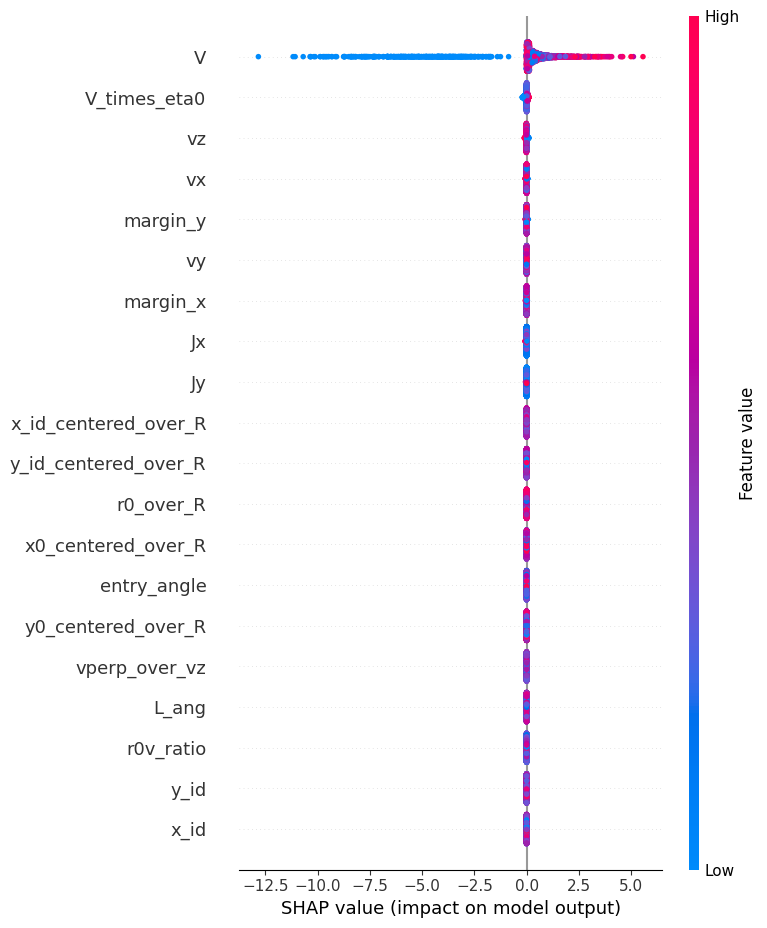

C:\Users\ogras\AppData\Local\Temp\ipykernel_82520\1353180888.py:160: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


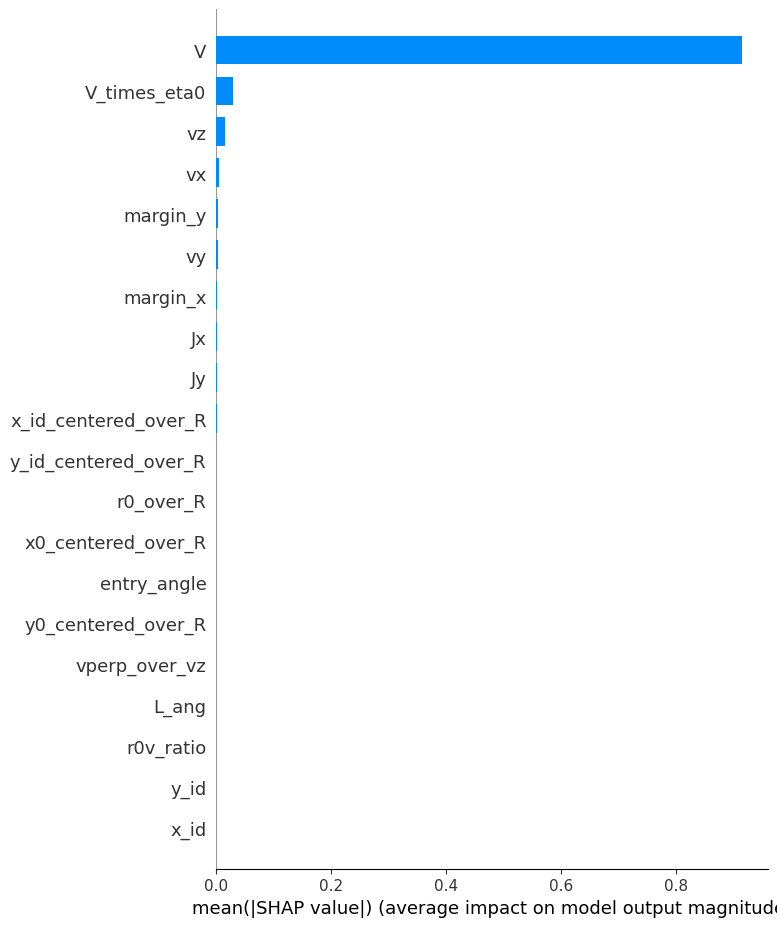


Top 20 features by mean |SHAP| (log-odds):
V                             0.913551
V_times_eta0                  0.029960
vz                            0.014640
vx                            0.004268
margin_y                      0.003253
vy                            0.002279
margin_x                      0.001980
Jx                            0.001894
Jy                            0.001850
x_id_centered_over_R          0.000725
y_id_centered_over_R          0.000337
r0_over_R                     0.000334
x0_centered_over_R            0.000266
entry_angle                   0.000130
y0_centered_over_R            0.000110
vperp_over_vz                 0.000094
L_ang                         0.000039
r0v_ratio                     0.000032
y_id                          0.000012
x_id                          0.000008


In [26]:
# === SHAP (GradientExplainer on LOGITS) — PASTE-RUN ===
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt

# ----------------------------
# 0) Feature names (from dummy raw)
# ----------------------------
dummy_raw = np.zeros((1, 6), dtype=np.float32)  # [x0, y0, vx, vy, vz, V]
_, feature_names = augment_with_physics_extended_smooth(
    dummy_raw, R=R, L=L, alpha0=alpha0, mass=particle.mass, return_names=True
)

# ----------------------------
# 1) Background (TRAIN) & Eval (VALID)
# ----------------------------
rng = np.random.default_rng(42)
bg_n = min(2048, len(data_tr_full.X))
eval_n = min(5000, len(data_va_full.X))
bg_idx = rng.choice(len(data_tr_full.X), size=bg_n, replace=False)
eval_idx = rng.choice(len(data_va_full.X), size=eval_n, replace=False)

X_bg = data_tr_full.X[bg_idx].astype(np.float32)  # already augmented
X_eval = data_va_full.X[eval_idx].astype(np.float32)  # already augmented


# (optional) drop any non-finite rows that might have leaked in
def _finite_rows(X):
    m = np.isfinite(X).all(axis=1)
    return X[m], m


X_bg, _ = _finite_rows(X_bg)
X_eval, _ = _finite_rows(X_eval)

# ----------------------------
# 2) Model wrapper: LOGITS (N,1)
# ----------------------------
device = next(clf.parameters()).device
clf.eval().to(device)


class LogitWrapper(torch.nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        out = self.base(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        if out.dim() == 1:
            out = out.unsqueeze(-1)
        return out  # logits (N,1)


logit_model = LogitWrapper(clf).eval().to(device)


# ----------------------------
# 3) K-means background → ndarray
# ----------------------------
def _kmeans_ndarray(X, k=512):
    km = shap.kmeans(X, k)
    if hasattr(km, "data"):  # new SHAP
        return km.data
    if hasattr(km, "values"):  # older SHAP
        return km.values
    return np.asarray(km)


try:
    X_bg_k = _kmeans_ndarray(X_bg, k=min(512, max(32, X_bg.shape[0] // 4)))
except Exception:
    # Fallback to random subset if kmeans not available
    n2 = min(4096, len(X_bg))
    ridx = np.random.default_rng(0).choice(len(X_bg), size=n2, replace=False)
    X_bg_k = X_bg[ridx]

X_bg_t = torch.tensor(X_bg_k, dtype=torch.float32, device=device, requires_grad=True)
X_eval_t = torch.tensor(X_eval[:4000], dtype=torch.float32, device=device)

# ----------------------------
# 4) SHAP GradientExplainer (logits)
# ----------------------------
explainer = shap.GradientExplainer(logit_model, X_bg_t)
shap_vals = explainer.shap_values(X_eval_t)


# ----------------------------
# 5) Normalize SHAP shape to (n_samples, n_features)
# ----------------------------
def _normalize_shap(sv, X_ref):
    import numpy as _np
    import torch as _torch

    if isinstance(sv, list):
        sv = sv[0]
    if isinstance(sv, _torch.Tensor):
        sv = sv.detach().cpu().numpy()
    sv = _np.asarray(sv)
    ns, nf = X_ref.shape
    if sv.ndim == 2:
        if sv.shape == (ns, nf):
            return sv
        if sv.shape == (nf, ns):
            return sv.T
    if sv.ndim == 3:
        # (n_outputs, n_samples, n_features) or variants
        if sv.shape[0] == 1 and sv.shape[1] == ns and sv.shape[2] == nf:
            return sv[0]
        if sv.shape[0] == ns and sv.shape[1] == 1 and sv.shape[2] == nf:
            return sv[:, 0, :]
        if sv.shape[0] == 1 and sv.shape[1] == nf and sv.shape[2] == ns:
            return sv[0].T
        if sv.shape[0] == nf and sv.shape[1] == 1 and sv.shape[2] == ns:
            return sv[:, 0, :].T
        # squeeze singleton dims and retry
        s = _np.squeeze(sv)
        if s.ndim == 2:
            if s.shape == (ns, nf):
                return s
            if s.shape == (nf, ns):
                return s.T
    raise ValueError(
        f"Could not normalize SHAP shape {sv.shape} to (n_samples, n_features)={X_ref.shape}."
    )


shap_vals = _normalize_shap(shap_vals, X_eval_t.cpu().numpy())
X_eval_used = X_eval[: shap_vals.shape[0]]

# If names are out-of-sync with columns, fall back to generic names
if len(feature_names) != X_eval_used.shape[1]:
    feature_names = [f"f{i}" for i in range(X_eval_used.shape[1])]

# (optional) ensure finite
finite_mask = np.isfinite(X_eval_used).all(axis=1) & np.isfinite(shap_vals).all(axis=1)
if not finite_mask.all():
    X_eval_used = X_eval_used[finite_mask]
    shap_vals = shap_vals[finite_mask]

print(
    "Shapes → shap_vals:",
    shap_vals.shape,
    "  X_eval_used:",
    X_eval_used.shape,
    "  #names:",
    len(feature_names),
)

# ----------------------------
# 6) Plots (log-odds units)
# ----------------------------
shap.summary_plot(shap_vals, X_eval_used, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_vals, X_eval_used, feature_names=feature_names, plot_type="bar", show=False
)
plt.tight_layout()
plt.show()

# ----------------------------
# 7) Ranking + dependence helper
# ----------------------------
mean_abs = np.mean(np.abs(shap_vals), axis=0)
order = np.argsort(mean_abs)[::-1]
print("\nTop 20 features by mean |SHAP| (log-odds):")
for j in order[:20]:
    print(f"{feature_names[j]:28s}  {mean_abs[j]:.6f}")


def shap_dependence(feature: str, color_by: str | None = None):
    i = feature_names.index(feature)
    j = feature_names.index(color_by) if (color_by in feature_names) else "auto"
    shap.dependence_plot(
        i,
        shap_vals,
        X_eval_used,
        feature_names=feature_names,
        interaction_index=j,
        show=False,
    )
    plt.tight_layout()
    plt.show()


# Examples:
# shap_dependence("margin_y", color_by="eta0")
# shap_dependence("k", color_by="r0_over_R")


# ----------------------------
# 8) Optional PDP (probability space) helper
# ----------------------------
@torch.no_grad()
def _model_proba_np(X):
    x = torch.tensor(X, dtype=torch.float32, device=device)
    p = torch.sigmoid(clf(x)).squeeze(-1).cpu().numpy()
    return p


def pdp(feature: str, X_ref: np.ndarray, q=(1, 99), n=60):
    j = feature_names.index(feature)
    lo, hi = np.percentile(X_ref[:, j], q)
    grid = np.linspace(lo, hi, n)
    Xc = X_ref.copy()
    ys = []
    for g in grid:
        Xc[:, j] = g
        ys.append(_model_proba_np(Xc).mean())
    plt.plot(grid, ys)
    plt.xlabel(feature)
    plt.ylabel("mean P(survive)")
    plt.tight_layout()
    plt.show()


# Examples:
# pdp("margin_y", X_eval_used)
# pdp("vperp_over_vz", X_eval_used)


In [27]:
import numpy as np
from sklearn.metrics import average_precision_score
import torch


def pr_auc(model, X, y, device):
    with torch.no_grad():
        p = (
            torch.sigmoid(model(torch.tensor(X, dtype=torch.float32, device=device)))
            .cpu()
            .numpy()
            .ravel()
        )
    return average_precision_score(y, p)


def perm_importance(model, X, y, names, device, n_repeats=5, rng=42):
    rng = np.random.default_rng(rng)
    base = pr_auc(model, X, y, device)
    drops = []
    for j in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            scores.append(pr_auc(model, Xp, y, device))
        drops.append(base - np.mean(scores))
    order = np.argsort(drops)[::-1]
    for j in order[:20]:
        print(f"{names[j]:28s}  ΔPR-AUC={drops[j]:.5f}")
    return drops, base


drops, base = perm_importance(
    clf, data_va_full.X.astype(np.float32), data_va_full.y, feature_names, device
)


Jy                            ΔPR-AUC=0.00443
Jx                            ΔPR-AUC=0.00418
V                             ΔPR-AUC=0.00385
entry_angle                   ΔPR-AUC=0.00039
margin_y                      ΔPR-AUC=0.00033
vperp_over_vz                 ΔPR-AUC=0.00031
vy                            ΔPR-AUC=0.00021
r0v_ratio                     ΔPR-AUC=0.00009
L_ang                         ΔPR-AUC=0.00003
y0_centered_over_R            ΔPR-AUC=0.00002
y_id_centered_over_R          ΔPR-AUC=0.00002
y_id                          ΔPR-AUC=0.00000
y0                            ΔPR-AUC=0.00000
k                             ΔPR-AUC=0.00000
cos_kL                        ΔPR-AUC=0.00000
sin_kL                        ΔPR-AUC=-0.00000
x0                            ΔPR-AUC=-0.00000
t_transit                     ΔPR-AUC=-0.00000
y_sag0                        ΔPR-AUC=-0.00000
eta0                          ΔPR-AUC=-0.00000
